In [13]:
# Imports
import numpy as np
import os
import kagglehub
import imageio.v2 as iio
import keras.utils
import keras
import cv2
from matplotlib import pyplot as plt

In [3]:
dataset_path = "./data.npz"
def load_data():
    # if os.path.isfile(dataset_path):
        # print("Cache file found. Using it.")
        # data = np.load(dataset_path, allow_pickle=True)
        # return (data["images"], data["labels"], data["categories"].item())

    path = kagglehub.dataset_download("aryaminus/electronic-components")
    path += "/images"
    print(f'Loading dataset from {path}')
    src_categories = os.listdir(path)
    for x in src_categories:
        if not os.path.isdir(path + "/" + x):
            print(f"remove {x}")
            src_categories.remove(x)

    categories = {}
    i = 0
    for c in src_categories:
        categories[c] = i
        i += 1
    data_images = []
    data_labels = []
    stats = {}
    for c in categories:
        dirpath = path + "/" + c
        files = os.listdir(dirpath)
        stats[c] = len(files)
        for f in files:
            filepath = dirpath + "/" + f
            if os.path.isdir(filepath):
                continue
            img = iio.imread(filepath)
            if img.ndim == 2:
                img = np.stack([img] * 3, axis=-1)
            # RGBA -> RGB
            elif img.shape[-1] == 4:
                img = img[:, :, :3]

            img = cv2.resize(img, (128, 64), interpolation=cv2.INTER_AREA)
            data_images.append(img)
            data_labels.append(categories[c])
    # convert to float
    data_images = np.array(data_images)
    data_images = data_images.astype("float32") / 255.0
    data_labels = np.array(data_labels)
    np.savez(dataset_path, images=data_images, labels=data_labels, categories=categories)
    return (data_images, data_labels, categories, stats)

(X_data, Y_data, categories, stats) = load_data()
perm = np.random.permutation(len(X_data))

X_data = X_data[perm]
Y_data = Y_data[perm]

Loading dataset from /kaggle/input/datasets/aryaminus/electronic-components/images


In [ ]:
plt.imshow(X_data[0])
print(Y_data[0])
print(len(X_data))
print(X_data.min(), X_data.max(), X_data.dtype)
print(len(X_data), len(categories))

In [ ]:
print("| Category | Number of images |")
print("| ---:|:--- |")
for s in stats:
  print(f"| {s} | {stats[s]} |")

In [4]:
from sklearn.model_selection import train_test_split

input_shape = X_data.shape[1:]

X_train, X_test, Y_train, Y_test = train_test_split(
    X_data, Y_data,
    test_size=0.2,
    random_state=42,
    stratify=Y_data
)
X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")
Y_train, Y_test = keras.utils.to_categorical(Y_train, len(categories)), keras.utils.to_categorical(Y_test, len(categories))

In [5]:
IMG_SIZE = (224,224)

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.03),
    keras.layers.RandomZoom(0.10),
#    keras.layers.RandomTranslation(0.08, 0.08),
    keras.layers.RandomTranslation(0.04, 0.04),
#    keras.layers.RandomContrast(0.2),
])

# base_model = keras.applications.MobileNetV2(
   # input_shape=(224, 224, 3),
   # include_top=False,
   # weights="imagenet"
# )
base_model = keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# base_model = keras.applications.ResNet50(
    # input_shape=(224,224,3),
    # include_top=False,
    # weights="imagenet"
# )

base_model.trainable = False

inputs = keras.Input(shape=input_shape)

x = keras.layers.Resizing(224, 224)(inputs)
x = data_augmentation(x)
# from keras.applications.mobilenet_v2 import preprocess_input
# x = preprocess_input(x * 255.0)   # only if X_data is normalized to 0..1

from keras.applications.efficientnet import preprocess_input
x = preprocess_input(x * 255.0)   # only if X_data is normalized to 0..1

# from keras.applications.resnet50 import preprocess_input
# x = preprocess_input(x * 255.0)   # only if X_data is normalized to 0..1

x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.3)(x)

outputs = keras.layers.Dense(len(categories), activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


I0000 00:00:1781442150.819701      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 128, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,096,968 (15.63 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [28]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=input_shape))

model.add(keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
model.add(keras.layers.Dropout(0.25))

model.add(keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
model.add(keras.layers.Dropout(0.25))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.Dense(64, activation='relu'))

# Output layer
model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.Dense(len(categories), activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 126, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 31, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 59, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 13, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 24128)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 24128)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     1,544,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,622,309 (6.19 MB)

 Trainable params: 1,622,309 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(loss='categorical_crossentropy',
              optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              metrics=['accuracy'])

In [30]:
batch_size = 64
epochs = 40

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    mode="min",
    patience=5,             # epochs without improvement
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(X_train, Y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(X_test, Y_test),
                    callbacks=[early_stopping, reduce_lr]
                    )

Epoch 1/40


I0000 00:00:1781446280.522758     132 service.cc:152] XLA service 0x7b4120421970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781446280.522836     132 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 10/138 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0323 - loss: 3.7008

I0000 00:00:1781446285.150799     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.0521 - loss: 3.5101 - val_accuracy: 0.1096 - val_loss: 3.3258 - learning_rate: 0.0010
Epoch 2/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0934 - loss: 3.3087 - val_accuracy: 0.1124 - val_loss: 3.2321 - learning_rate: 0.0010
Epoch 3/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.1179 - loss: 3.1778 - val_accuracy: 0.1474 - val_loss: 3.1142 - learning_rate: 0.0010
Epoch 4/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.1385 - loss: 3.0859 - val_accuracy: 0.1565 - val_loss: 3.0309 - learning_rate: 0.0010
Epoch 5/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.1503 - loss: 2.9993 - val_accuracy: 0.1733 - val_loss: 2.9779 - learning_rate: 0.0010
Epoch 6/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.1729 - loss: 2.9009 - val_accuracy: 0.1729 - val_loss: 2.9553 - learning_rate: 0.0010
Epoch 7/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.1926 - loss: 2.8150 - val

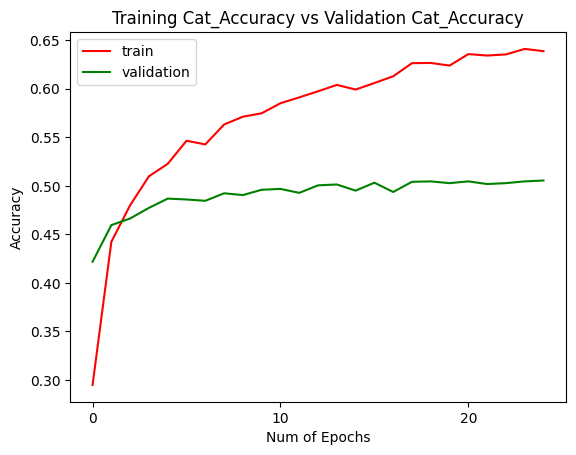

In [8]:
n_epochs = len(history.history['loss'])

plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'g')
plt.xticks(np.arange(0, n_epochs, 10.0))
plt.rcParams['figure.figsize'] = (8, 6)
plt.xlabel("Num of Epochs")
plt.ylabel("Accuracy")
plt.title("Training Cat_Accuracy vs Validation Cat_Accuracy")
plt.legend(['train','validation'])
plt.savefig("accuracy_pretune.png")
plt.show()


In [ ]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

In [9]:
# fine turning
base_model.trainable = True

ft_epohs = 40

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    mode="min",
      patience=8,             # epochs without improvement
      restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_ft = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=ft_epohs,
    batch_size=batch_size,
    callbacks=[early_stopping, reduce_lr]
)



Epoch 1/40


E0000 00:00:1781442583.193850      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


138/138 ━━━━━━━━━━━━━━━━━━━━ 35s 144ms/step - accuracy: 0.4752 - loss: 1.8026 - val_accuracy: 0.4713 - val_loss: 1.7672 - learning_rate: 1.0000e-05
Epoch 2/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.5140 - loss: 1.6610 - val_accuracy: 0.4641 - val_loss: 1.8156 - learning_rate: 1.0000e-05
Epoch 3/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.5299 - loss: 1.5782 - val_accuracy: 0.4659 - val_loss: 1.7955 - learning_rate: 1.0000e-05
Epoch 4/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.5442 - loss: 1.5240 - val_accuracy: 0.4700 - val_loss: 1.7650 - learning_rate: 1.0000e-05
Epoch 5/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.5587 - loss: 1.4703 - val_accuracy: 0.4727 - val_loss: 1.7401 - learning_rate: 1.0000e-05
Epoch 6/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.5618 - loss: 1.4410 - val_accuracy: 0.4745 - val_loss: 1.7187 - learning_rate: 1.0000e-05
Epoch 7/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - 

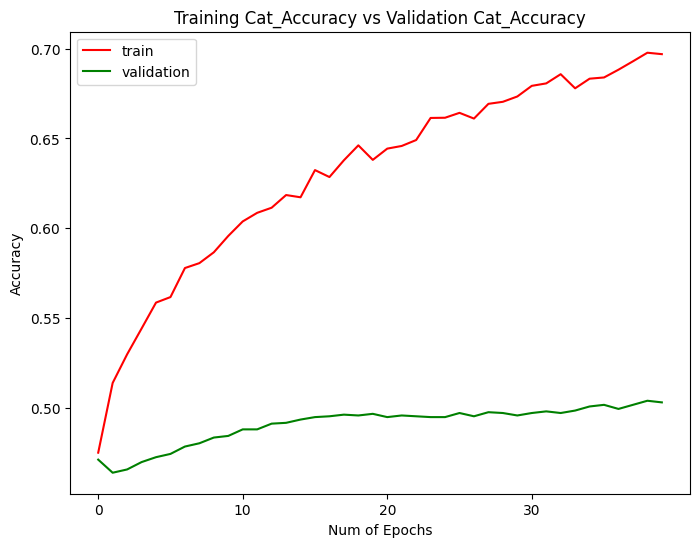

In [10]:
plt.plot(history_ft.history['accuracy'],'r')
plt.plot(history_ft.history['val_accuracy'],'g')
plt.xticks(np.arange(0, ft_epohs, 10.0))
plt.rcParams['figure.figsize'] = (8, 6)
plt.xlabel("Num of Epochs")
plt.ylabel("Accuracy")
plt.title("Training Cat_Accuracy vs Validation Cat_Accuracy")
plt.legend(['train','validation'])
plt.savefig("accuracy_posttune.png")
plt.show()


In [ ]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

display_labels = [i for i in categories]

y_true = np.argmax(Y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(categories)))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

disp.plot(xticks_rotation=90)
plt.savefig('confusion_matrix.png')
plt.savefig('confusion_matrix.svg', format='svg', bbox_inches='tight')
plt.show()

20
Expected: junction-transistor; got PNP-transistor


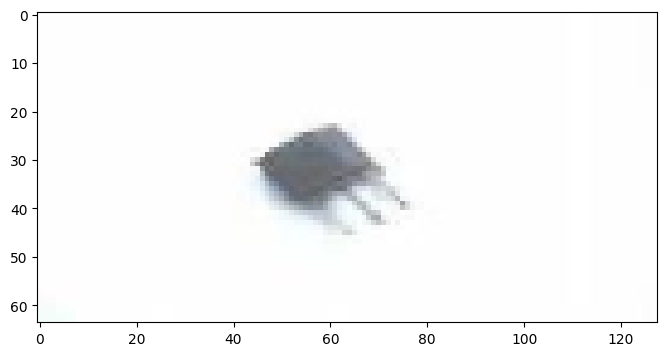

In [26]:
y_expected = "junction-transistor"
y_real = "PNP-transistor"
# y_expected = "electric-relay"
# y_real = "relay"
y_expected_i = categories[y_expected]
y_real_i = categories[y_real]
example_img_idx = -1
for i in range(len(y_true)):
    if y_true[i] == y_expected_i and y_pred[i] == y_real_i:
        example_img_idx = i
        break
print(example_img_idx)
if example_img_idx == -1:
    print("No image found")
else:
    plt.imshow(X_test[example_img_idx])
    plt.savefig(f'expected_{y_expected}_got_{y_real}.png')
    print(f"Expected: {y_expected}; got {y_real}")